In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split


In [7]:
import pandas as pd

df = pd.read_pickle(
    r"C:\Users\moazz\Desktop\Earthquake_Project\dataset\df_train.csv"
)


### SOME REGULAR EDA(EXPLORATARY DATA ANALYSIS) TO GET TO KNOW WHAT KIND OF OUR REALLY IS 


In [8]:

df.shape

(34289, 45)

In [9]:
df.columns

Index(['level_0', 'index', 'E_channel', 'N_channel', 'E_channel_precursors',
       'N_channel_precursors', 'Z_channel_precursors', 'Z_channel',
       'back_azimuth_deg', 'coda_end_sample', 'network_code',
       'p_arrival_sample', 'p_status', 'p_travel_sec', 'p_weight',
       'receiver_code', 'receiver_elevation_m', 'receiver_latitude',
       'receiver_longitude', 'receiver_type', 's_arrival_sample', 's_status',
       's_weight', 'snr_db', 'source_depth_km', 'source_depth_uncertainty_km',
       'source_distance_deg', 'source_distance_km', 'source_error_sec',
       'source_gap_deg', 'source_horizontal_uncertainty_km', 'source_id',
       'source_latitude', 'source_longitude', 'source_magnitude',
       'source_magnitude_author', 'source_magnitude_type',
       'source_mechanism_strike_dip_rake', 'source_origin_time',
       'source_origin_uncertainty_sec', 'trace_category', 'trace_name',
       'trace_start_time', 'missing_time_from_event',
       'source_magnitude_label'],
    

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34289 entries, 0 to 34288
Data columns (total 45 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   level_0                           34289 non-null  int64         
 1   index                             34289 non-null  int64         
 2   E_channel                         34289 non-null  object        
 3   N_channel                         34289 non-null  object        
 4   E_channel_precursors              34289 non-null  object        
 5   N_channel_precursors              34289 non-null  object        
 6   Z_channel_precursors              34289 non-null  object        
 7   Z_channel                         34289 non-null  object        
 8   back_azimuth_deg                  34289 non-null  object        
 9   coda_end_sample                   34289 non-null  object        
 10  network_code                      34289 non-nu

In [11]:
df.head()

,level_0,index,E_channel,N_channel,E_channel_precursors,N_channel_precursors,Z_channel_precursors,Z_channel,back_azimuth_deg,coda_end_sample,...,source_magnitude_author,source_magnitude_type,source_mechanism_strike_dip_rake,source_origin_time,source_origin_uncertainty_sec,trace_category,trace_name,trace_start_time,missing_time_from_event,source_magnitude_label
0,6000,2508,"[-0.0, -0.3037471, -0.7941901, -2.0677443, -2....","[-0.0, -0.1688106, -0.4445446, -1.1667616, -1....","[-174.67068, -160.9165, -111.053535, -55.44577...","[-165.62244, -131.0894, -92.94777, -50.196747,...","[34.627823, 6.5667224, -19.73172, -63.976402, ...","[-0.0, -0.040024515, -0.085517466, -0.22547446...",136.0,[[3199.0]],...,None,ml,None,2018-06-15 07:09:57.260,None,earthquake_local,HSSD.HV_20180615070953_EV,2018-06-15 07:09:54.030,-3.23,"[0, 0, 1, 0, 0]"
1,6001,177771,"[0.0, 0.008827989, 0.027690079, 0.050335042, 0...","[0.0, 0.0067506083, 0.017026894, 0.0626213, 0....","[11.102617, 20.359272, 22.870697, 9.638555, 11...","[18.403194, 5.542464, -8.4973955, -8.423143, 0...","[4.857739, 13.261822, 16.091331, 21.411762, 15...","[0.0, 0.0044994447, 0.012301209, 0.036946297, ...",204.300003,[[3097.0]],...,None,ml,None,2009-07-15 00:58:07.600,0.83,earthquake_local,CERT.IV_20090715005807_EV,2009-07-15 00:58:08.900,1.30,"[0, 0, 0, 1, 0]"
2,6002,143069,"[-0.0, -0.07114574, -0.07915803, 0.045831945, ...","[-0.0, -0.11352274, -0.40909925, -0.6154829, -...","[550.5055, 621.12805, 494.6476, 227.99667, -8....","[672.15076, 618.96216, 396.99496, 218.53148, 9...","[-51.757576, 128.74973, 153.27184, 69.25438, 4...","[-0.0, -0.02897907, 0.03212849, 0.31494758, 0....",46.099998,[[1928.0]],...,None,ml,None,2003-02-22 13:37:30.670,None,earthquake_local,SVD.CI_20030222133726_EV,2003-02-22 13:37:27.020,-3.65,"[0, 1, 0, 0, 0]"
3,6003,176271,"[-4.039773, -5.0321927, -3.098704, -2.0527992,...","[-1.1656461, -0.06951267, 2.7692225, 2.9919803...","[6.2956905, 10.219786, 5.2689557, -0.8171556, ...","[0.7568476, 2.7275038, 0.7710497, 2.6436691, 3...","[0.84727585, -0.23956358, -0.18065163, 3.83636...","[-0.33165205, -1.1276397, -0.23394835, -0.2988...",309.799988,[[2641.0]],...,None,ml,None,2018-07-26 18:46:42.410,None,earthquake_local,B084.PB_20180726184643_EV,2018-07-26 18:46:43.600,1.19,"[0, 0, 0, 1, 0]"
4,6004,44864,"[0.0, 0.0046114475, 0.01731589, 0.057890795, 0...","[-0.0, -0.008839174, -0.03844553, -0.08942565,...","[-42.98916, -48.740185, -76.14363, -64.10923, ...","[-28.852701, -9.431699, -17.502617, -8.581977,...","[30.556585, 10.862256, 45.766666, 30.64336, 17...","[0.0, 0.06398069, 0.17558555, 0.45652658, 0.61...",334.899994,[[3199.0]],...,None,ml,None,2013-03-13 22:34:50.480,0.82,earthquake_local,DOI.IV_20130313223451_EV,2013-03-13 22:34:52.420,1.94,"[0, 0, 1, 0, 0]"


In [12]:
type(df["Z_channel"].iloc[0])


numpy.ndarray

In [13]:
len(df["Z_channel"].iloc[0])


6000

In [14]:
df[["p_arrival_sample", "s_arrival_sample"]].head()


,p_arrival_sample,s_arrival_sample
0,898,1322.0
1,900,1730.0
2,900,1317.0
3,1000,1811.0
4,900,1677.0


In [15]:
df["Z_channel"].apply(len).value_counts()


Z_channel
6000    34289
Name: count, dtype: int64

### Plotting Only 1 Signal

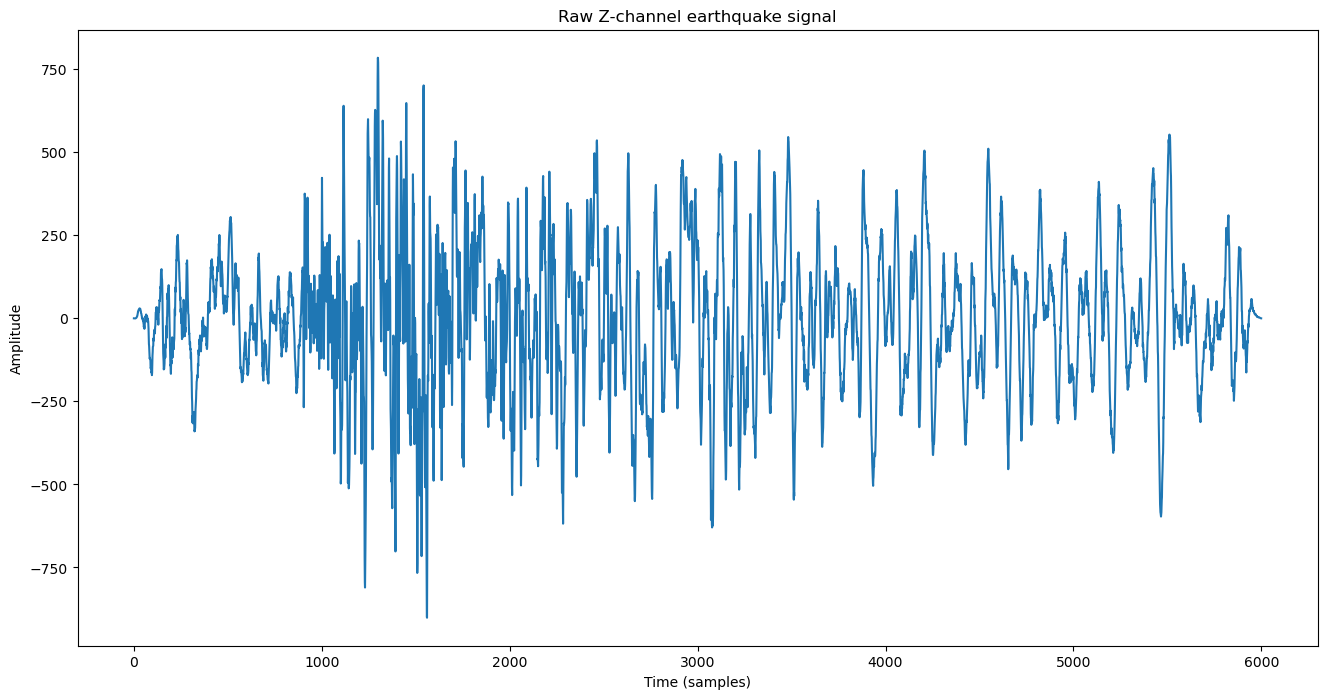

In [16]:
import matplotlib.pyplot as plt

signal = df["Z_channel"].iloc[0]

plt.figure(figsize=(16,8))
plt.plot(signal)
plt.title("Raw Z-channel earthquake signal")
plt.xlabel("Time (samples)")
plt.ylabel("Amplitude")
plt.show()


#### In above figure we see that:
##### - X axis(0 ---> 6000) represent time moving forward(moment by moment)
##### - Y axis(Up and Down) represent up and down how much the ground moved up/down at that moment


### MARKING P and S arrival

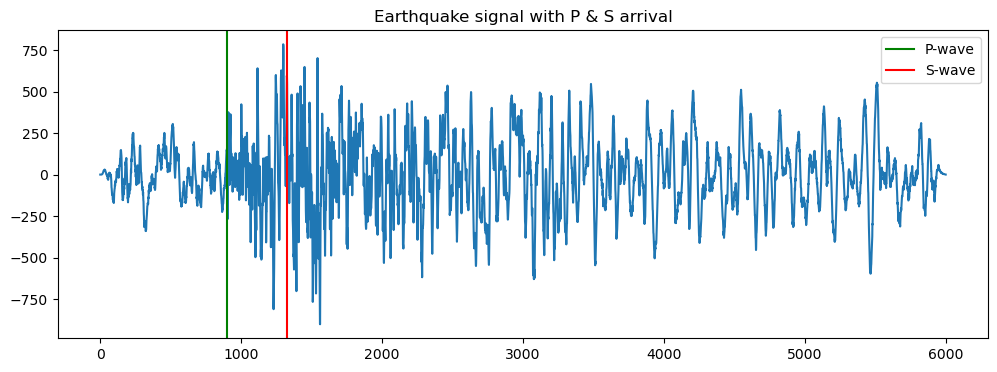

In [ ]:
p = df["p_arrival_sample"].iloc[0]
s = df["s_arrival_sample"].iloc[0]

plt.figure(figsize=(12,4))
plt.plot(signal)
plt.axvline(p, color="green", label="P-wave")
plt.axvline(s, color="red", label="S-wave")
plt.legend()
plt.title("Earthquake signal with P & S arrival")
plt.show()



# For Baseline Model (Regression Model)


In [18]:
# Scipy is a scientific library of python,Signal is subset of that library for waves/signals ,butter creates a butterworth filter(a kind
# of filter ) filfit applies the filter backward + forward

from scipy.signal import butter, filtfilt

# sr is sampling rate low removes anything below 1hz high remove anything above 20hz, simplest idea keep shaking between 1-20 hz throw away
# rest of the shit

def bandpass_filter(signal, sr=100, low=1, high=20):
    nyqf = 0.5 * sr #nyqf is Nyquist Frequency(hald of sampling rate) by half cuz signals from the system can only be trusted upto half the sr rate
    
#creating the filter
    b, a = butter(
        N=4, # it defines the sharpness of the filter
        Wn=[low/nyqf, high/nyqf],
        btype="band"
    )
    return filtfilt(b, a, signal)


In [19]:
# Applying filter to 1 Signal
Raw_Sig = df["Z_channel"].iloc[0]
filt_sig = bandpass_filter(Raw_Sig)


In [20]:
# Normalizing the signal
import numpy as np

# This function make all the signal values small and controlled

def normalize(signal):
    max_val = np.max(np.abs(signal))
    if max_val == 0:
        return signal  # keep zero signal as-is
    return signal / max_val


# np.abs(signal) - convert all the values to positive
#np.max(np.abs(signal)) - Find the largest value in the Signal




clean_sig = normalize(filt_sig)


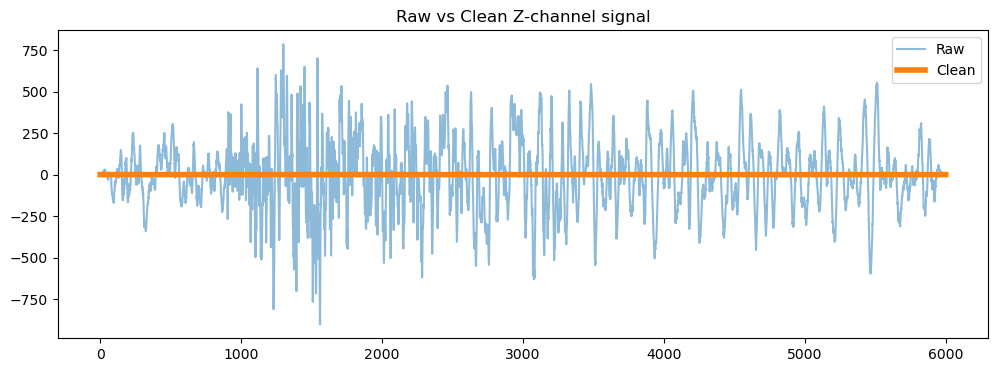

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
plt.plot(Raw_Sig, label="Raw", alpha=0.5)
plt.plot(clean_sig, label="Clean", linewidth=4)
plt.legend()
plt.title("Raw vs Clean Z-channel signal")
plt.show()


In [22]:
#Applying Preprocessing on the whole dataset

def preprocess_signal(signal):
    signal = bandpass_filter(signal)
    signal = normalize(signal)
    return signal

X = np.stack(df["Z_channel"].apply(preprocess_signal).values)

y = df[["p_arrival_sample", "s_arrival_sample"]].values


In [23]:
def extract_features(signal):
    return [
        np.mean(signal),          # average movement
        np.std(signal),           # how shaky-shaky it is
        np.max(signal),           # strongest upward movement
        np.min(signal),           # strongest downward movement
        np.sum(signal**2)         # total energy
    ]


In [24]:
X_new = np.array(
    df["Z_channel"].apply(extract_features).tolist()
)


In [25]:
X_new.shape


(34289, 5)

In [26]:
y_new = df[["p_arrival_sample", "s_arrival_sample"]].values


In [27]:

from sklearn.model_selection import train_test_split

Xb_train, Xb_val, yb_train, yb_val = train_test_split(
    X_new,
    y_new,
    test_size=0.2,
    random_state=42
)


In [28]:
from sklearn.ensemble import RandomForestRegressor

baseline_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

baseline_model.fit(Xb_train, yb_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
from sklearn.metrics import mean_absolute_error

preds = baseline_model.predict(Xb_val)

mae_p = mean_absolute_error(yb_val[:,0], preds[:,0])
mae_s = mean_absolute_error(yb_val[:,1], preds[:,1])

print("Baseline MAE (P-wave):", mae_p)
print("Baseline MAE (S-wave):", mae_s)


Baseline MAE (P-wave): 38.41584135316419
Baseline MAE (S-wave): 265.3535799470417


# PreProcessing

In [30]:
# 1. Drop rows with bad labels
df = df.dropna(subset=["p_arrival_sample", "s_arrival_sample"])

# 2. Remove zero-only signals
df = df[df["Z_channel"].apply(lambda x: np.max(np.abs(x)) > 0)]

print("After cleaning:", len(df))


After cleaning: 34287


In [31]:
TARGET_LEN = 6000  # use your real length

def fix_length(sig):
    if len(sig) > TARGET_LEN:
        return sig[:TARGET_LEN]
    if len(sig) < TARGET_LEN:
        return np.pad(sig, (0, TARGET_LEN - len(sig)))
    return sig

df["Z_channel"] = df["Z_channel"].apply(fix_length)


In [32]:
def normalize_signal(sig):
    max_val = np.max(np.abs(sig))
    if max_val == 0:
        return sig
    return sig / max_val

df["Z_channel"] = df["Z_channel"].apply(normalize_signal)


In [33]:
X = np.array(df["Z_channel"].to_list(), dtype=np.float32)

y = df[["p_arrival_sample", "s_arrival_sample"]].to_numpy(
    dtype=np.float32
)


In [34]:
signal_length = X.shape[1]
y = y / signal_length


In [35]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [36]:
X_train = X_train[:, None, :]
X_val   = X_val[:, None, :]


In [37]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val, dtype=torch.float32)
y_val_t   = torch.tensor(y_val, dtype=torch.float32)

train_ds = TensorDataset(X_train_t, y_train_t)
val_ds   = TensorDataset(X_val_t, y_val_t)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False)


In [38]:
class ArrivalCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(1, 16, 7, padding=3),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(16, 32, 5, padding=2),
            nn.ReLU(),
            nn.MaxPool1d(2),
            nn.Conv1d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.fc = nn.Linear(64, 2)

    def forward(self, x):
        x = self.features(x)
        return self.fc(x.squeeze(-1))


In [39]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = ArrivalCNN().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


In [36]:
epochs = 30

for epoch in range(epochs):
    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    model.eval()
    val_loss = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            val_loss += criterion(preds, yb).item()

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss/len(train_loader):.4f} | "
        f"Val Loss: {val_loss/len(val_loader):.4f}"
    )


Epoch 1/30 | Train Loss: 0.0015 | Val Loss: 0.0013
Epoch 2/30 | Train Loss: 0.0013 | Val Loss: 0.0012
Epoch 3/30 | Train Loss: 0.0012 | Val Loss: 0.0012
Epoch 4/30 | Train Loss: 0.0012 | Val Loss: 0.0012
Epoch 5/30 | Train Loss: 0.0012 | Val Loss: 0.0011
Epoch 6/30 | Train Loss: 0.0012 | Val Loss: 0.0012
Epoch 7/30 | Train Loss: 0.0012 | Val Loss: 0.0011
Epoch 8/30 | Train Loss: 0.0012 | Val Loss: 0.0011
Epoch 9/30 | Train Loss: 0.0011 | Val Loss: 0.0011
Epoch 10/30 | Train Loss: 0.0011 | Val Loss: 0.0012
Epoch 11/30 | Train Loss: 0.0011 | Val Loss: 0.0011
Epoch 12/30 | Train Loss: 0.0011 | Val Loss: 0.0011
Epoch 13/30 | Train Loss: 0.0011 | Val Loss: 0.0011
Epoch 14/30 | Train Loss: 0.0011 | Val Loss: 0.0011
Epoch 15/30 | Train Loss: 0.0011 | Val Loss: 0.0011
Epoch 16/30 | Train Loss: 0.0011 | Val Loss: 0.0010
Epoch 17/30 | Train Loss: 0.0011 | Val Loss: 0.0011
Epoch 18/30 | Train Loss: 0.0010 | Val Loss: 0.0011
Epoch 19/30 | Train Loss: 0.0010 | Val Loss: 0.0011
Epoch 20/30 | Train L

In [40]:
with torch.no_grad():
    preds = model(X_val_t.to(device)).cpu().numpy()

pred_samples = preds * signal_length
true_samples = y_val * signal_length

mae = np.mean(np.abs(pred_samples - true_samples), axis=0)
print("P MAE:", mae[0], "samples")
print("S MAE:", mae[1], "samples")


P MAE: 1434.8748 samples
S MAE: 965.4348 samples


In [1]:
with open(r"C:\Users\moazz\Desktop\Earthquake_Project\dataset\df_train.csv", "rb") as f:
    print(f.read(200))


b'\x80\x05\x95\xcd\x01\x00\x00\x00\x00\x00\x00\x8c\x11pandas.core.frame\x94\x8c\tDataFrame\x94\x93\x94)\x81\x94}\x94(\x8c\x04_mgr\x94\x8c\x1epandas.core.internals.managers\x94\x8c\x0cBlockManager\x94\x93\x94(\x8c\x16pandas._libs.internals\x94\x8c\x0f_unpickle_block\x94\x93\x94\x8c\x13pandas._libs.arrays\x94\x8c\x1c__pyx_unpickle_NDArray'


In [4]:
import pandas as pd

df = pd.read_pickle(r"C:\Users\moazz\Desktop\Earthquake_Project\dataset\df_train.csv")
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].astype(str)

df.to_parquet("converted.parquet", engine="pyarrow")



In [5]:
import duckdb

con = duckdb.connect()

# Preview first 20 rows
df_preview = con.execute("SELECT * FROM 'converted.parquet' LIMIT 20").fetchdf()
df_preview


,level_0,index,E_channel,N_channel,E_channel_precursors,N_channel_precursors,Z_channel_precursors,Z_channel,back_azimuth_deg,coda_end_sample,...,source_magnitude_author,source_magnitude_type,source_mechanism_strike_dip_rake,source_origin_time,source_origin_uncertainty_sec,trace_category,trace_name,trace_start_time,missing_time_from_event,source_magnitude_label
0,6000,2508,[-0. -0.3037471 -0.7941901 ... -0.19...,[-0. -0.1688106 -0.4445446 ... 0.05...,[-1.74670685e+02 -1.60916504e+02 -1.11053535e+...,[-165.62244 -131.0894 -92.94777 -50.1...,[ 3.46278229e+01 6.56672239e+00 -1.97317200e+...,[-0. -0.04002452 -0.08551747 ... 0.11...,136.0,[[3199.]],...,None,ml,None,2018-06-15 07:09:57.260,None,earthquake_local,HSSD.HV_20180615070953_EV,2018-06-15 07:09:54.030,-3.230,"[0, 0, 1, 0, 0]"
1,6001,177771,[ 0. 0.00882799 0.02769008 ... 0.00...,[ 0. 0.00675061 0.01702689 ... 0.02...,[ 11.102617 20.359272 22.870697 9.63...,[ 1.84031944e+01 5.54246378e+00 -8.49739552e+...,[ 4.85773897e+00 1.32618217e+01 1.60913315e+...,[0. 0.00449944 0.01230121 ... 0.041608...,204.3,[[3097.]],...,None,ml,None,2009-07-15 00:58:07.600,0.83,earthquake_local,CERT.IV_20090715005807_EV,2009-07-15 00:58:08.900,1.300,"[0, 0, 0, 1, 0]"
2,6002,143069,[-0. -0.07114574 -0.07915803 ... 0.24...,[-0. -0.11352274 -0.40909925 ... 0.32...,[ 5.50505493e+02 6.21128052e+02 4.94647614e+...,[ 672.15076 618.96216 396.99496 2...,[ -51.757576 128.74973 153.27184 ...,[-0. -0.02897907 0.03212849 ... 0.34...,46.1,[[1928.]],...,None,ml,None,2003-02-22 13:37:30.670,None,earthquake_local,SVD.CI_20030222133726_EV,2003-02-22 13:37:27.020,-3.650,"[0, 1, 0, 0, 0]"
3,6003,176271,[ -4.039773 -5.0321927 -3.098704 ... -50.2...,[ -1.1656461 -0.06951267 2.7692225 ... ...,[ 6.2956905 10.219786 5.2689557 -0.817155...,[ 0.7568476 2.7275038 0.7710497 2.64...,[ 8.47275853e-01 -2.39563584e-01 -1.80651635e-...,[ -0.33165205 -1.1276397 -0.23394835 ... -5...,309.8,[[2641.]],...,None,ml,None,2018-07-26 18:46:42.410,None,earthquake_local,B084.PB_20180726184643_EV,2018-07-26 18:46:43.600,1.190,"[0, 0, 0, 1, 0]"
4,6004,44864,[0. 0.00461145 0.01731589 ... 0.030622...,[-0. -0.00883917 -0.03844553 ... 0.02...,[-4.29891586e+01 -4.87401848e+01 -7.61436310e+...,[-2.88527012e+01 -9.43169880e+00 -1.75026169e+...,[ 3.05565853e+01 1.08622561e+01 4.57666664e+...,[ 0. 0.06398069 0.17558555 ... -0.00...,334.9,[[3199.]],...,None,ml,None,2013-03-13 22:34:50.480,0.82,earthquake_local,DOI.IV_20130313223451_EV,2013-03-13 22:34:52.420,1.940,"[0, 0, 1, 0, 0]"
5,6005,199459,[ -127.14762 -83.16291 -63.790165 ... -...,[ 366.439 269.2091 151.30698 ... -341....,[-3.33912170e+02 -2.91148071e+02 -2.72210144e+...,[ 5.26349831e+01 5.99390717e+01 1.09763275e+...,[-1.12387329e+02 -8.25879135e+01 -7.16174088e+...,[ 177.89603 165.6107 151.68088 ... -1797...,62.8,[[5999.]],...,None,ml,None,2018-07-14 00:09:20.620,None,earthquake_local,HOVE.HV_20180714000920_EV,2018-07-14 00:09:20.820,0.200,"[0, 0, 0, 1, 0]"
6,6006,8705,[-0. -0.00995104 -0.02618584 ... -0.02...,[0. 0.00489576 0.00306378 ... 0.023877...,[-8.13351593e+01 -9.07993851e+01 -9.43937531e+...,[ 4.31693802e+01 5.77891426e+01 7.38905869e+...,[ 8.23856735e+00 4.51564646e+00 3.36607385e+...,[ 0. 0.00051517 0.00239817 ... -0.00...,220.0,[[3199.]],...,None,md,None,2016-07-28 04:02:22.400,None,earthquake_local,AHUD.HV_20160728040218_EV,2016-07-28 04:02:19.310,-3.090,"[0, 1, 0, 0, 0]"
7,6007,148198,[0. 0.04641391 0.12156549 ... 0.012975...,[-0. -0.00414592 -0.01397773 ... -0.00...,[ 3.41695442e+01 2.73036804e+01 2.08183975e+...,[ 2.08805103e+01 1.07712917e+01 1.98039865e+...,[ 9.64498711e+00 9.11697292e+00 6.02141333e+...,[ 0. 0.04567124 0.12390344 ... -0.00...,94.8,[[3199.]],...,None,ml,None,2009-02-06 23:15:27.900,0.6,earthquake_local,BUG.GR_20090206231527_EV,2009-02-06 23:15:28.900,1.000,"[0, 0, 0, 1, 0]"
8,6008,96400,[-0. -0.3448996 -0.51132816 ... 0.51...,[ 0. 0.16078833 0.69112927 ... -1.43...,[ -807.62915 -426.27396 117.92069 1064....,[-1847.8495 -1807.6823 -1734.7417 -1830....,[-2.05984863

In [8]:
import duckdb
import dtale

con = duckdb.connect()

# Only load a safe amount first (important!)
query = """
SELECT *
FROM 'converted.parquet'
LIMIT 20000
"""

df = con.execute(query).df()

# Drop unnecessary index columns safely
df = df.drop(columns=["level_0", "index"], errors="ignore")

# Clean reset
df.reset_index(drop=True, inplace=True)

# Start D-Tale fresh
d = dtale.show(df, drop_index=True)
d.open_browser()
